In [33]:
import pandas as pd

In [34]:
filename = "student_feedback.csv"

In [35]:
df = pd.read_csv(filename)
df


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9
...,...,...,...,...,...,...,...,...,...,...
996,996,55,8,7,6,2,5,7,7,9
997,997,913,5,5,6,5,6,7,6,1
998,998,199,9,5,8,3,8,1,1,2
999,999,539,10,2,7,4,3,4,10,1


In [36]:
df_clean = df.drop(columns=['Unnamed: 0'])


In [37]:
df_clean

,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9
...,...,...,...,...,...,...,...,...,...
996,55,8,7,6,2,5,7,7,9
997,913,5,5,6,5,6,7,6,1
998,199,9,5,8,3,8,1,1,2
999,539,10,2,7,4,3,4,10,1


In [38]:
missing_values = df_clean.isnull().sum()

In [39]:
missing_values

,0
Student ID,0
Well versed with the subject,0
Explains concepts in an understandable way,0
Use of presentations,0
Degree of difficulty of assignments,0
Solves doubts willingly,0
Structuring of the course,0
Provides support for students going above and beyond,0
Course recommendation based on relevance,0


In [43]:
avg_scores = df_clean.drop(columns=['Student ID']).mean().sort_values(ascending=False)

In [44]:
avg_scores


,0
Well versed with the subject,7.497502
Explains concepts in an understandable way,6.081918
Use of presentations,5.942058
Provides support for students going above and beyond,5.662338
Structuring of the course,5.636364
Course recommendation based on relevance,5.598402
Solves doubts willingly,5.474525
Degree of difficulty of assignments,5.430569


In [45]:
overall_satisfaction = df_clean.drop(columns=['Student ID']).mean(axis=1)

In [46]:
overall_satisfaction

,0
0,5.000
1,4.875
2,4.375
3,5.875
4,7.500
...,...
996,6.375
997,5.125
998,4.625
999,5.125


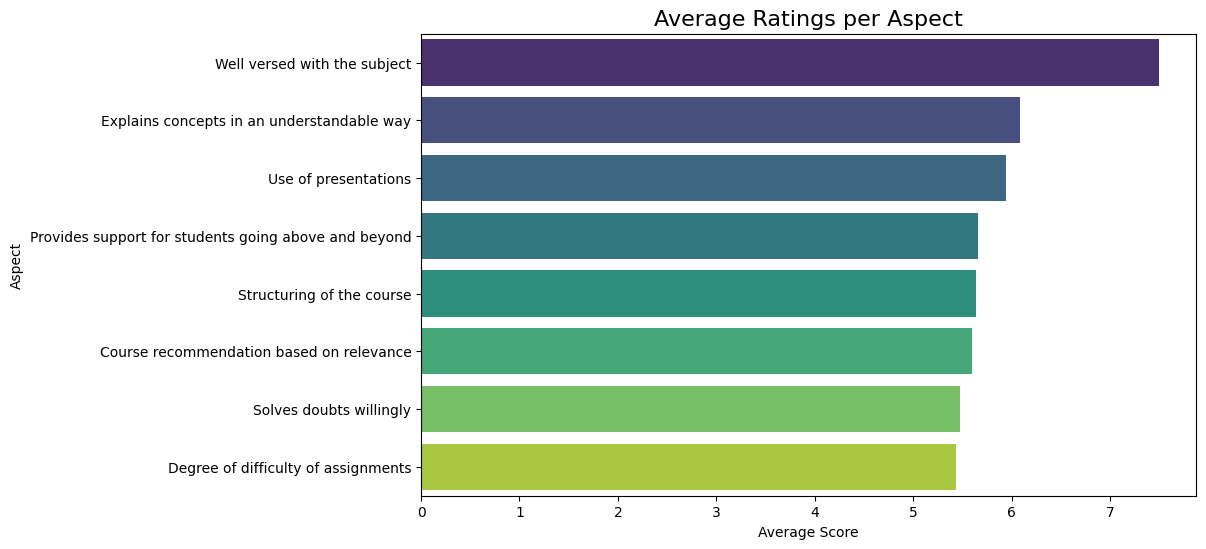

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(
x=avg_scores.values,
y=avg_scores.index,
hue=avg_scores.index,
palette="viridis",
legend=False # hide legend
)
plt.title("Average Ratings per Aspect", fontsize=16)
plt.xlabel("Average Score")
plt.ylabel("Aspect")
plt.show()


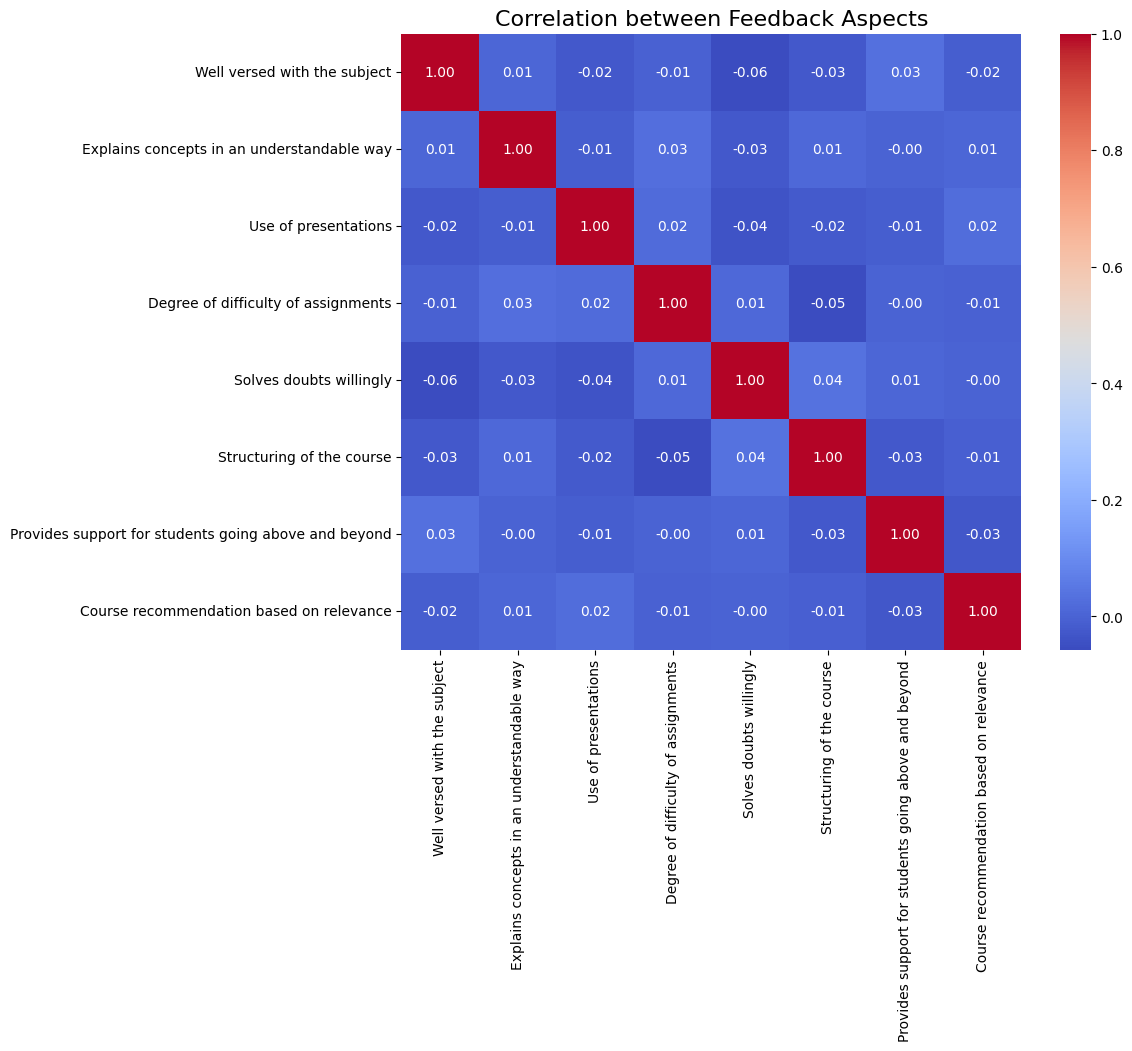

In [48]:
plt.figure(figsize=(10,8))
corr = df_clean.drop(columns=['Student ID']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Feedback Aspects", fontsize=16)
plt.show()


In [49]:
missing_values, avg_scores.head(), overall_satisfaction.head()

(Student ID                                              0
 Well versed with the subject                            0
 Explains concepts in an understandable way              0
 Use of presentations                                    0
 Degree of difficulty of assignments                     0
 Solves doubts willingly                                 0
 Structuring of the course                               0
 Provides support for students going above and beyond    0
 Course recommendation based on relevance                0
 dtype: int64,
 Well versed with the subject                            7.497502
 Explains concepts in an understandable way              6.081918
 Use of presentations                                    5.942058
 Provides support for students going above and beyond    5.662338
 Structuring of the course                               5.636364
 dtype: float64,
 0    5.000
 1    4.875
 2    4.375
 3    5.875
 4    7.500
 dtype: float64)

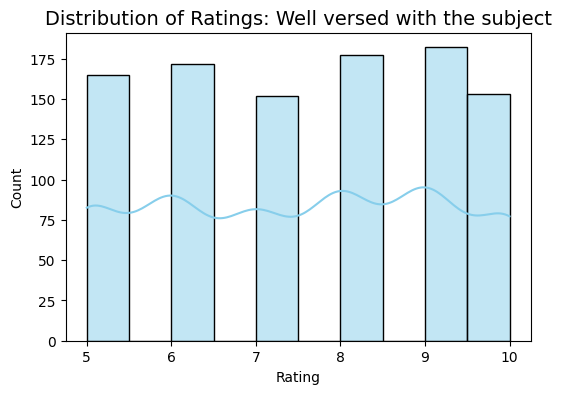

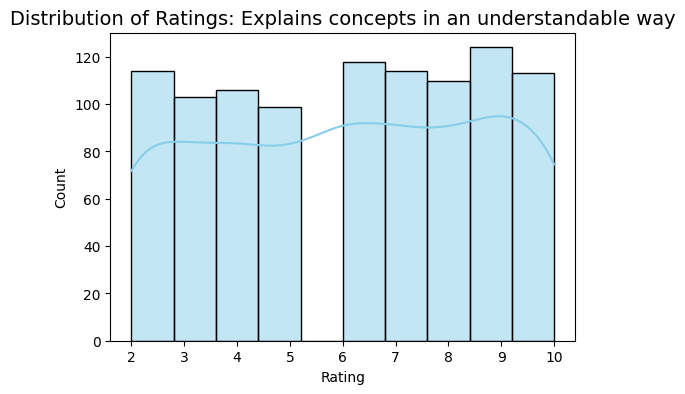

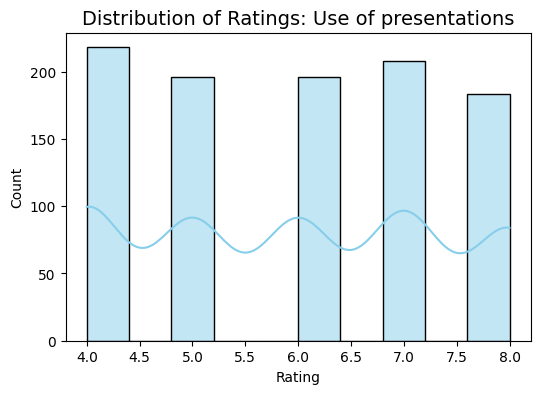

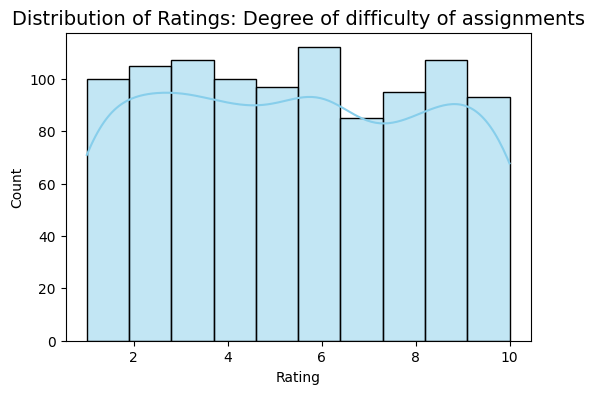

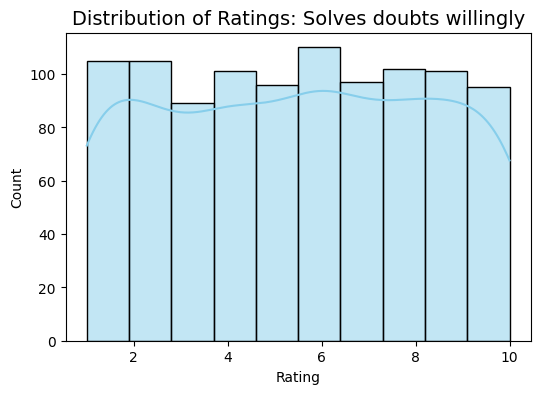

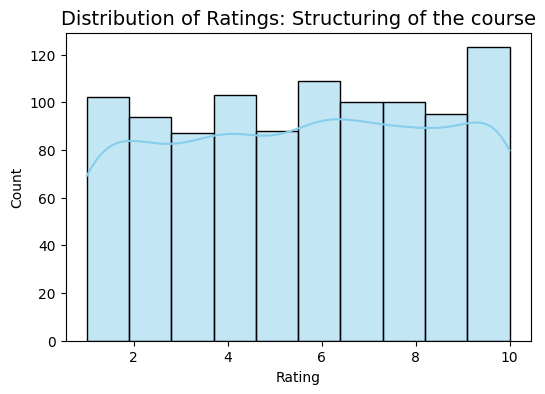

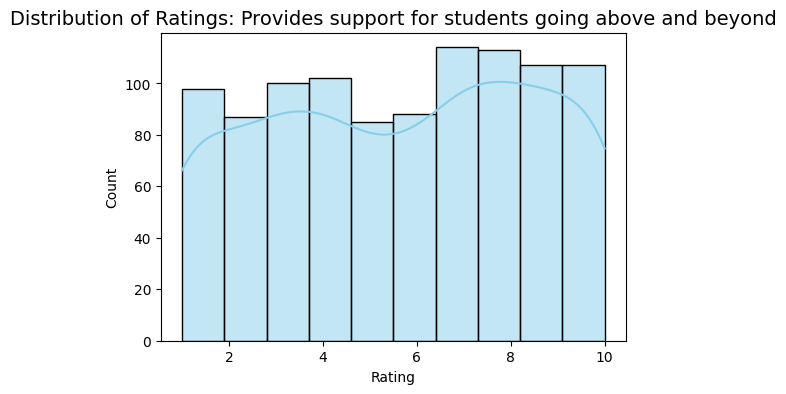

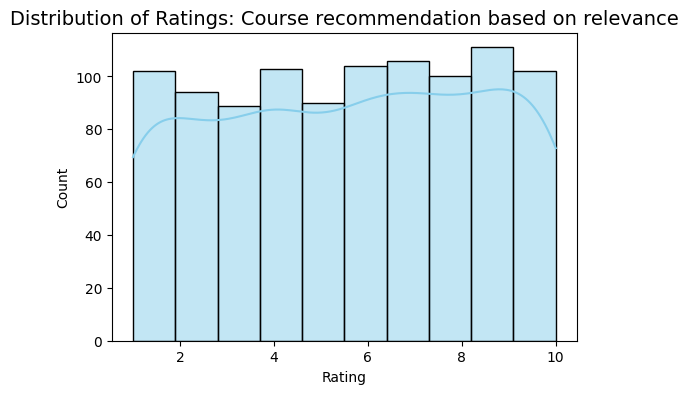

In [51]:
for col in df_clean.drop(columns=['Student ID']).columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df_clean[col], bins=10, kde=True, color='skyblue')
  plt.title(f"Distribution of Ratings: {col}", fontsize=14)
  plt.xlabel("Rating")
  plt.ylabel("Count")
  plt.show()


In [52]:
top_aspects = avg_scores.head(3)
bottom_aspects = avg_scores.tail(3)
top_aspects
bottom_aspects

,0
Course recommendation based on relevance,5.598402
Solves doubts willingly,5.474525
Degree of difficulty of assignments,5.430569


In [53]:
insights = {
"Top 3 Aspects": top_aspects.to_dict(),
"Bottom 3 Aspects": bottom_aspects.to_dict(),
"Overall Average Satisfaction": round(overall_satisfaction.mean(), 2),
"Highest Rating": round(avg_scores.max(), 2),
"Lowest Rating": round(avg_scores.min(), 2)
}


In [54]:
insights


{'Top 3 Aspects': {'Well versed with the subject': 7.497502497502498,
  'Explains concepts in an understandable way': 6.081918081918082,
  'Use of presentations': 5.942057942057942},
 'Bottom 3 Aspects': {'Course recommendation based on relevance': 5.5984015984015985,
  'Solves doubts willingly': 5.474525474525475,
  'Degree of difficulty of assignments': 5.430569430569431},
 'Overall Average Satisfaction': np.float64(5.92),
 'Highest Rating': 7.5,
 'Lowest Rating': 5.43}

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
import nltk


In [56]:
 from nltk.corpus import stopwords

In [58]:
import random
def generate_feedback(score):
  if score >= 8:
    return random.choice([
        "The course was excellent and very well structured.",
        "I really enjoyed the lectures and learned a lot.",
        "Great teaching style and very engaging sessions."
    ])
  elif score >= 5:
    return random.choice([
        "The course was okay but could be improved in some areas.",
        "Some topics were clear, others a bit confusing.",
        "Average experience, assignments were manageable."
    ])
  else:
    return random.choice([
        "The course was difficult to follow and needs improvement.",
        "I struggled to understand the concepts.",
        "Poor explanations and unclear assignments."
    ])

In [59]:
df_clean['Overall_Score'] = df_clean.drop(columns=['Student ID']).mean(axis=1)

In [60]:
df_clean['Feedback'] = df_clean['Overall_Score'].apply(generate_feedback)

In [61]:
df_clean.to_csv("student_feedback_with_comments.csv", index=False)


In [62]:
 print(df_clean[['Overall_Score', 'Feedback']].head())

   Overall_Score                                          Feedback
0          5.000  Average experience, assignments were manageable.
1          4.875           I struggled to understand the concepts.
2          4.375        Poor explanations and unclear assignments.
3          5.875  Average experience, assignments were manageable.
4          7.500   Some topics were clear, others a bit confusing.


In [64]:
feedback_column = "Feedback"
for col in df.columns:
    if 'feedback' in col.lower():
        feedback_column = col
        break
if not feedback_column:
    raise ValueError("No column containing 'feedback' found in the CSV.")

In [66]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()
    text = "".join(char for char in text if char.isalpha() or char.isspace())
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text
feedback_column = "Feedback"
df_clean['Cleaned_Feedback'] = df_clean[feedback_column].apply(clean_text)

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [67]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [68]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()
    text = "".join(char for char in text if char.isalpha() or char.isspace())
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text
feedback_column = "Feedback"
df_clean['Cleaned_Feedback'] = df_clean[feedback_column].apply(clean_text)

In [69]:
from textblob import TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'
df_clean['Sentiment'] = df_clean['Cleaned_Feedback'].apply(get_sentiment)
df_clean['Polarity'] = df_clean['Cleaned_Feedback'].apply(lambda x: TextBlob(x).sentiment.polarity)

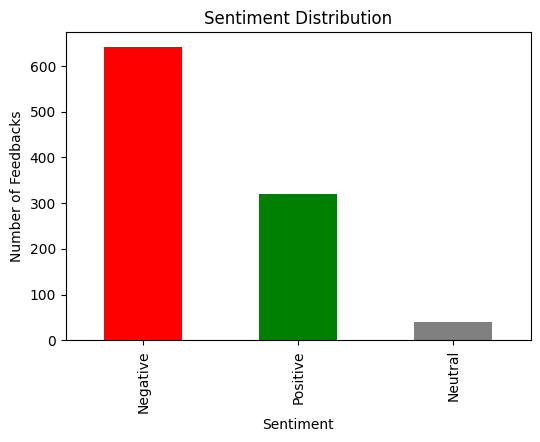

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df_clean['Sentiment'].value_counts().plot(kind='bar', color=['red','green','gray'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedbacks")
plt.show()

In [77]:
df_clean[[feedback_column, 'Sentiment', 'Polarity']].head(10)

,Feedback,Sentiment,Polarity
0,"Average experience, assignments were manageable.",Negative,-0.15
1,I struggled to understand the concepts.,Neutral,0.00
2,Poor explanations and unclear assignments.,Negative,-0.40
3,"Average experience, assignments were manageable.",Negative,-0.15
4,"Some topics were clear, others a bit confusing.",Negative,-0.10
5,Poor explanations and unclear assignments.,Negative,-0.40
6,"Average experience, assignments were manageable.",Negative,-0.15
7,"Average experience, assignments were manageable.",Negative,-0.15
8,The course was okay but could be improved in s...,Positive,0.50
9,The course was okay but could be improved in s...,Positive,0.50


In [78]:
import pandas as pd
df = pd.read_csv("student_feedback_with_comments.csv")
print(df.columns.tolist())
print(df.head())

['Student ID', 'Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance', 'Overall_Score', 'Feedback']
   Student ID  Well versed with the subject  \
0         340                             5   
1         253                             6   
2         680                             7   
3         806                             9   
4         632                             8   

   Explains concepts in an understandable way  Use of presentations  \
0                                           2                     7   
1                                           5                     8   
2                                           7                     6   
3                                           6                     7   
4                    

In [79]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print(df.columns)

Index(['student_id', 'well_versed_with_the_subject',
       'explains_concepts_in_an_understandable_way', 'use_of_presentations',
       'degree_of_difficulty_of_assignments', 'solves_doubts_willingly',
       'structuring_of_the_course',
       'provides_support_for_students_going_above_and_beyond',
       'course_recommendation_based_on_relevance', 'overall_score',
       'feedback'],
      dtype='object')


In [80]:
from textblob import TextBlob
import pandas as pd
df = pd.read_csv("student_feedback_with_comments.csv")
df.dropna(subset=['Feedback'], inplace=True)
df['Feedback'] = df['Feedback'].str.strip()
def analyze_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        sentiment = "Positive"
    elif polarity < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    return polarity, sentiment
df['sentiment_polarity'], df['sentiment_category'] = zip(*df['Feedback'].apply(analyze_sentiment))
df.to_csv("student_feedback_with_sentiment.csv", index=False)
print("Sentiment analysis complete. File saved as student_feedback_with_sentiment.csv")

Sentiment analysis complete. File saved as student_feedback_with_sentiment.csv
